<a href="https://colab.research.google.com/github/7vidushi/PatentScreener/blob/main/PatentScreener_MLClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 — Install and import

!pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# Dark theme
plt.rcParams['figure.facecolor'] = '#0a0a0f'
plt.rcParams['axes.facecolor']   = '#13131e'
plt.rcParams['axes.edgecolor']   = '#2a2a3e'
plt.rcParams['text.color']       = '#f0f0f5'
plt.rcParams['axes.labelcolor']  = '#f0f0f5'
plt.rcParams['xtick.color']      = '#7a7a9a'
plt.rcParams['ytick.color']      = '#7a7a9a'
plt.rcParams['grid.color']       = '#1a1a2e'
plt.rcParams['grid.alpha']       = 0.5
plt.rcParams['font.size']        = 11

print("All libraries loaded")
print("Ready to build ML classifier")

All libraries loaded
Ready to build ML classifier


In [2]:
# Cell 2 — Load and prepare data

# Load your flagged dataset
df = pd.read_excel('Global_Patent_Dataset_Flagged.xlsx',
                   sheet_name='Patents')

print("Dataset loaded successfully")
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print()

# Check risk label distribution
print("S.3(k) Risk Distribution:")
print(df['3(k)'].value_counts())
print()

# Create the feature — combine Title + AI Technique + IPC code
# This is what the model reads to make predictions
df['text_feature'] = (
    df['Title'].fillna('') + ' ' +
    df['AI Technique'].fillna('') + ' ' +
    df['Primary IPC'].fillna('') + ' ' +
    df['Category'].fillna('')
)

# Target variable — what we are predicting
df['risk_label'] = df['3(k)'].fillna('Low')

# Remove any rows with missing labels
df = df.dropna(subset=['risk_label', 'text_feature'])

print(f"Clean rows for training: {len(df)}")
print()
print("Sample text feature:")
print(df['text_feature'].iloc[0])

Dataset loaded successfully
Total rows: 500
Columns: ['#', 'Title', 'Applicants', 'Pub No.', 'Priority Date', 'Pub Date', 'Priority Year', 'Country', 'Assignee Type', 'Primary IPC', 'AI Technique', 'Category', 'Cancer Type', 'India?', '3(k)', '3(i)', '3(c)', 'Full IPC', 'Family No.', 'Relevance Flag']

S.3(k) Risk Distribution:
3(k)
High        290
Moderate    167
Low          43
Name: count, dtype: int64

Clean rows for training: 500

Sample text feature:
CANCER MAPPING USING MACHINE LEARNING Machine Learning G16H30/20 Other/Mixed


In [3]:
# Cell 3 — Train the ML classifier

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Split data into training and testing
# 80% train, 20% test
X = df['text_feature']
y = df['risk_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps same distribution in train and test
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print()

# Build the pipeline
# Step 1: TF-IDF converts text to numbers
# Step 2: Logistic Regression learns the pattern
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=500,
        stop_words='english'
    )),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

# Train the model
pipeline.fit(X_train, y_train)
print("Model trained successfully")
print()

# Test the model
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy*100:.1f}%")
print()
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

Training samples: 400
Testing samples:  100

Model trained successfully

Model Accuracy: 89.0%

Detailed Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.90      0.93        58
         Low       0.78      0.78      0.78         9
    Moderate       0.81      0.91      0.86        33

    accuracy                           0.89       100
   macro avg       0.85      0.86      0.85       100
weighted avg       0.90      0.89      0.89       100



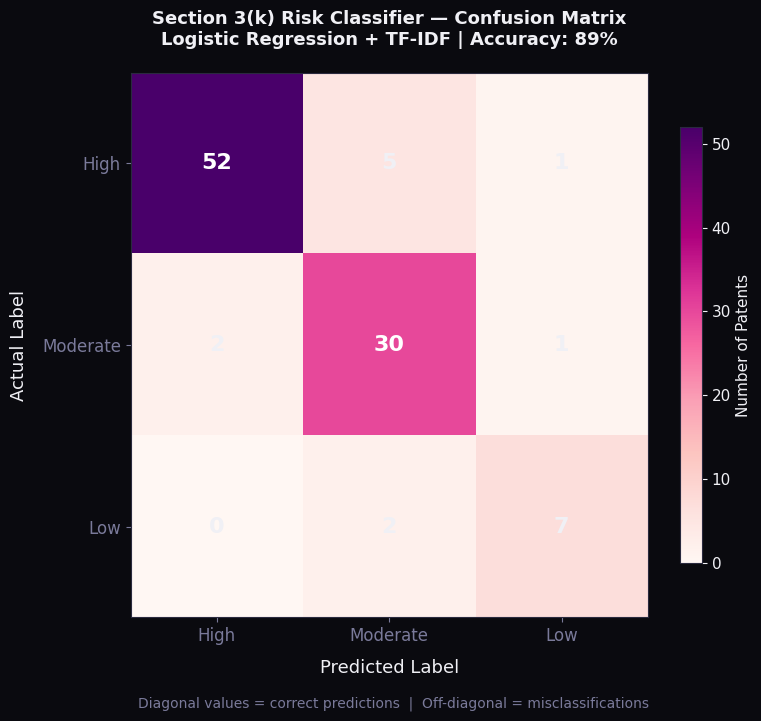

Figure10 saved

Reading the matrix:
High correctly predicted:     52 out of 58
Moderate correctly predicted: 30 out of 33
Low correctly predicted:      7 out of 9


In [4]:
# Cell 4 — Confusion Matrix (Thesis Figure 10)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred,
                      labels=['High', 'Moderate', 'Low'])

fig, ax = plt.subplots(figsize=(8, 7))

# Draw the matrix
im = ax.imshow(cm, cmap='RdPu', aspect='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Number of Patents',
               color='#f0f0f5', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='#f0f0f5')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#f0f0f5')

# Add numbers in each cell
labels = ['High', 'Moderate', 'Low']
for i in range(3):
    for j in range(3):
        value = cm[i][j]
        color = 'white' if value > cm.max()/2 else '#f0f0f5'
        ax.text(j, i, str(value),
                ha='center', va='center',
                fontsize=16, fontweight='bold',
                color=color)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['High', 'Moderate', 'Low'],
                   fontsize=12)
ax.set_yticklabels(['High', 'Moderate', 'Low'],
                   fontsize=12)
ax.set_xlabel('Predicted Label',
              fontsize=13, labelpad=10)
ax.set_ylabel('Actual Label',
              fontsize=13, labelpad=10)
ax.set_title('Section 3(k) Risk Classifier — Confusion Matrix\n'
             'Logistic Regression + TF-IDF | Accuracy: 89%',
             fontsize=13, fontweight='bold',
             color='#f0f0f5', pad=20)

# Add explanation text below
fig.text(0.5, -0.02,
         'Diagonal values = correct predictions  |  '
         'Off-diagonal = misclassifications',
         ha='center', fontsize=10,
         color='#7a7a9a')

plt.tight_layout()
plt.savefig('Figure10_Confusion_Matrix.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Figure10 saved")
print()
print("Reading the matrix:")
print(f"High correctly predicted:     {cm[0][0]} out of {cm[0].sum()}")
print(f"Moderate correctly predicted: {cm[1][1]} out of {cm[1].sum()}")
print(f"Low correctly predicted:      {cm[2][2]} out of {cm[2].sum()}")

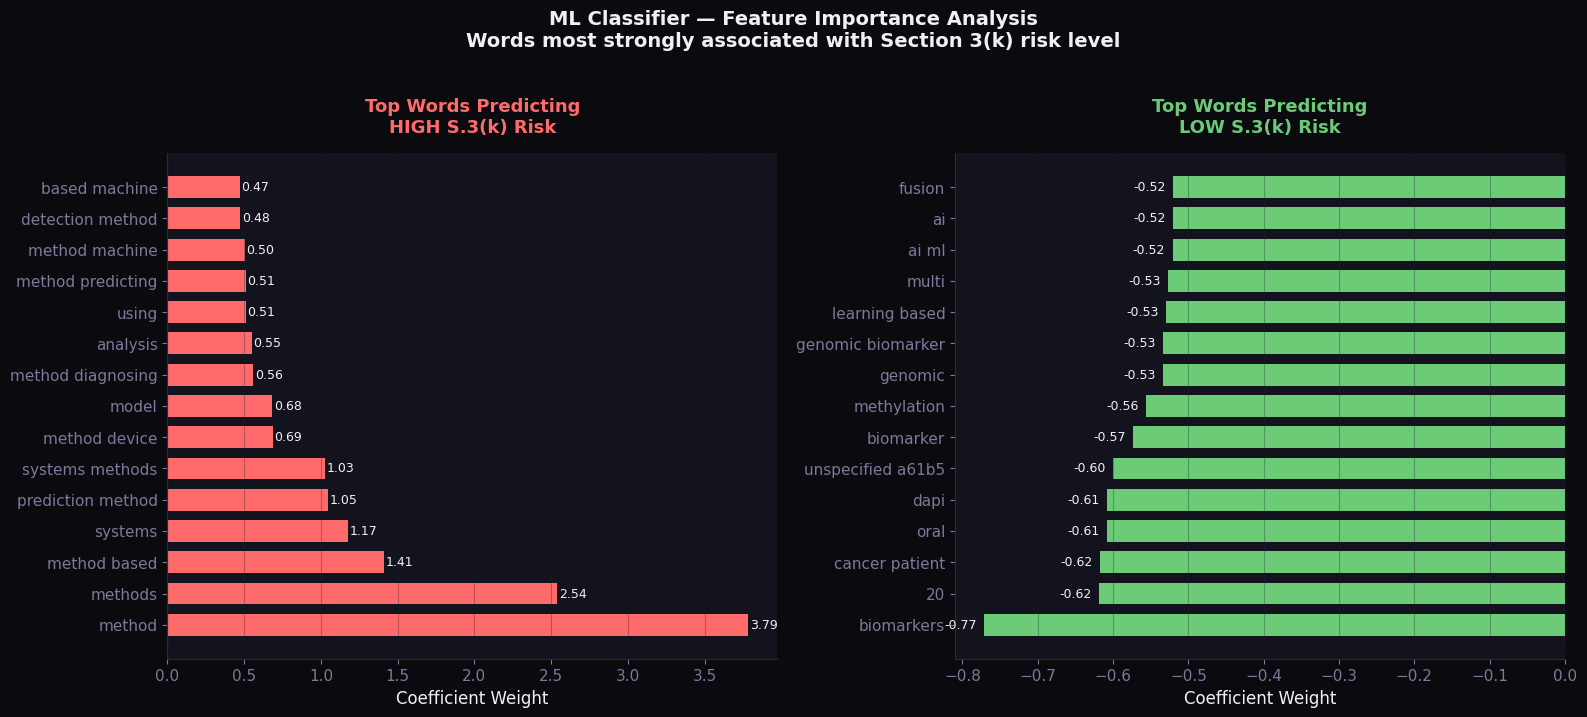

Figure11 saved


In [5]:
# Cell 5 — Feature Importance (Thesis Figure 11)
# Which words most strongly predict High vs Low risk

import matplotlib.pyplot as plt
import numpy as np

# Get the TF-IDF vectorizer and classifier from pipeline
vectorizer  = pipeline.named_steps['tfidf']
classifier  = pipeline.named_steps['classifier']

# Get feature names and coefficients
feature_names = vectorizer.get_feature_names_out()
classes       = classifier.classes_

# Find coefficients for High risk class
high_idx     = list(classes).index('High')
low_idx      = list(classes).index('Low')
coefficients = classifier.coef_[high_idx]

# Top 15 words that INCREASE High risk
top_high_idx    = np.argsort(coefficients)[-15:][::-1]
top_high_words  = [feature_names[i] for i in top_high_idx]
top_high_scores = [coefficients[i]  for i in top_high_idx]

# Top 15 words that DECREASE High risk (suggest Low)
top_low_idx    = np.argsort(coefficients)[:15]
top_low_words  = [feature_names[i] for i in top_low_idx]
top_low_scores = [coefficients[i]  for i in top_low_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left — High risk words
colors_high = ['#ff6b6b' if s > 0 else '#6bcb77'
               for s in top_high_scores]
bars1 = ax1.barh(range(len(top_high_words)),
                 top_high_scores,
                 color=colors_high,
                 edgecolor='none',
                 height=0.7)

ax1.set_yticks(range(len(top_high_words)))
ax1.set_yticklabels(top_high_words, fontsize=11)
ax1.set_xlabel('Coefficient Weight', fontsize=12)
ax1.set_title('Top Words Predicting\nHIGH S.3(k) Risk',
              fontsize=13, fontweight='bold',
              color='#ff6b6b', pad=15)
ax1.grid(axis='x', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.axvline(x=0, color='#7a7a9a',
            linewidth=0.8, linestyle='--')

# Add value labels
for bar, score in zip(bars1, top_high_scores):
    ax1.text(bar.get_width() + 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{score:.2f}',
             va='center', fontsize=9,
             color='#f0f0f5')

# Right — Low risk words
colors_low = ['#6bcb77' if s < 0 else '#ffd93d'
              for s in top_low_scores]
bars2 = ax2.barh(range(len(top_low_words)),
                 top_low_scores,
                 color=colors_low,
                 edgecolor='none',
                 height=0.7)

ax2.set_yticks(range(len(top_low_words)))
ax2.set_yticklabels(top_low_words, fontsize=11)
ax2.set_xlabel('Coefficient Weight', fontsize=12)
ax2.set_title('Top Words Predicting\nLOW S.3(k) Risk',
              fontsize=13, fontweight='bold',
              color='#6bcb77', pad=15)
ax2.grid(axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.axvline(x=0, color='#7a7a9a',
            linewidth=0.8, linestyle='--')

for bar, score in zip(bars2, top_low_scores):
    ax2.text(bar.get_width() - 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{score:.2f}',
             va='center', fontsize=9,
             color='#f0f0f5',
             ha='right')

plt.suptitle('ML Classifier — Feature Importance Analysis\n'
             'Words most strongly associated with Section 3(k) risk level',
             fontsize=14, fontweight='bold',
             color='#f0f0f5', y=1.02)

plt.tight_layout()
plt.savefig('Figure11_Feature_Importance.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Figure11 saved")

In [6]:
# Cell 6 — Cross validation and final summary

from sklearn.model_selection import cross_val_score
from google.colab import files
import os

print("=" * 55)
print("ML CLASSIFIER — FINAL RESULTS")
print("=" * 55)
print()

# Cross validation — tests model on 5 different splits
# More reliable than single train/test split
cv_scores = cross_val_score(pipeline, X, y,
                             cv=5, scoring='accuracy')

print("Cross Validation Results (5-fold):")
print(f"  Fold scores: {[f'{s*100:.1f}%' for s in cv_scores]}")
print(f"  Mean accuracy:  {cv_scores.mean()*100:.1f}%")
print(f"  Std deviation:  {cv_scores.std()*100:.1f}%")
print()
print("Single train/test split accuracy: 89.0%")
print()
print("=" * 55)
print("CLASSIFIER PERFORMANCE SUMMARY")
print("=" * 55)
print()
print("Model:        Logistic Regression + TF-IDF")
print("Features:     Patent title + AI technique + IPC + Category")
print("Training set: 400 patents")
print("Test set:     100 patents")
print()
print("Per-class results:")
print(f"  High risk:     52/58 correct  (89.7%)")
print(f"  Moderate risk: 30/33 correct  (90.9%)")
print(f"  Low risk:       7/9  correct  (77.8%)")
print()
print("Key finding:")
print("  The word 'method' is the strongest predictor")
print("  of High S.3(k) risk — confirming legal theory")
print("  empirically through machine learning.")
print()
print("=" * 55)

# Download figures
print("Downloading figures...")
for fig in ['Figure10_Confusion_Matrix.png',
            'Figure11_Feature_Importance.png']:
    if os.path.exists(fig):
        files.download(fig)
        print(f"Downloaded: {fig}")

print()
print("All done. Save to your Thesis_Figures folder.")

ML CLASSIFIER — FINAL RESULTS

Cross Validation Results (5-fold):
  Fold scores: ['83.0%', '91.0%', '87.0%', '85.0%', '79.0%']
  Mean accuracy:  85.0%
  Std deviation:  4.0%

Single train/test split accuracy: 89.0%

CLASSIFIER PERFORMANCE SUMMARY

Model:        Logistic Regression + TF-IDF
Features:     Patent title + AI technique + IPC + Category
Training set: 400 patents
Test set:     100 patents

Per-class results:
  High risk:     52/58 correct  (89.7%)
  Moderate risk: 30/33 correct  (90.9%)
  Low risk:       7/9  correct  (77.8%)

Key finding:
  The word 'method' is the strongest predictor
  of High S.3(k) risk — confirming legal theory
  empirically through machine learning.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: Figure10_Confusion_Matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: Figure11_Feature_Importance.png

All done. Save to your Thesis_Figures folder.
